In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
systems = {
    'H2':  (['H', 'H'],
            np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])),
    'LiH': (['Li', 'H'],
            np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 3.0]])),
    'H2O': (['O', 'H', 'H'],
            np.array([[0.0, 0.0, 0.28377432],
                      [0.0, 1.45278171, -1.00662237],
                      [0.0, -1.45278171, -1.00662237]])),
    'NH3': (['N', 'H', 'H', 'H'],
            np.array([[0.0, 0.0, 0.0],
                      [0.0, 1.77, 0.74],
                      [1.53, -0.88, 0.74],
                      [-1.53, -0.88, 0.74]])),
}

names, qubit_counts, gate_counts = [], [], []
for name, (sym, geo) in systems.items():
    m = qml.qchem.Molecule(sym, geo, basis_name='sto-3g')
    _, o, t = qml.qchem.electron_integrals(m)()
    est = qml.estimator.DoubleFactorization(o, t)
    names.append(name); qubit_counts.append(est.qubits); gate_counts.append(est.gates)
    print(f"{name}: qubits={est.qubits}, Toffoli={est.gates:.3e}")

H2: qubits=113, Toffoli=8.764e+05
LiH: qubits=263, Toffoli=1.478e+07
H2O: qubits=290, Toffoli=1.040e+08
NH3: qubits=314, Toffoli=1.045e+08


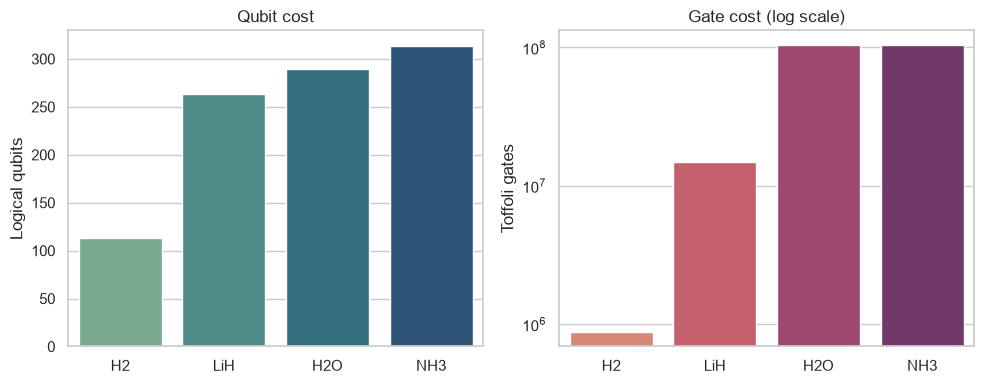

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=names, y=qubit_counts, ax=ax1, hue=names, legend=False, palette="crest")
ax1.set_ylabel("Logical qubits")
ax1.set_title("Qubit cost")

sns.barplot(x=names, y=gate_counts, ax=ax2, hue=names, legend=False, palette="flare")
ax2.set_ylabel("Toffoli gates")
ax2.set_yscale("log")
ax2.set_title("Gate cost (log scale)")

plt.tight_layout()
plt.savefig("resource_scaling.png", dpi=120, bbox_inches="tight")
plt.show()